In [ ]:
#!pip install datasets

import torch
import torch.nn as nn

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
# impport pad and pack sequence for variable length sequences
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence, pack_sequence
DEVICE = "cpu"
if torch.cuda.is_available():
    DEVICE = "cuda"
    print("CUDA device found.", torch.cuda.is_available())
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    print ("MPS device found.", torch.backends.mps.is_available())
else:
    print("Using CPU device.")

# Text Generation

## Word Sized Tokens

This example will tokenize each word. There are many, many examples online of character level text generation as well. Recreating one of those is a good exercise, almost everything will be the same as this, just with adaptations for the different tokens. 

In [2]:
#!pip install datasets
from datasets import load_dataset

#ds = load_dataset("jamescalam/reddit-python")
ds = load_dataset("SocialGrep/one-million-reddit-confessions")
text_data = ds["train"]["selftext"]
text_data = [t for t in ds["train"]["selftext"] if not t is None]
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['type', 'id', 'subreddit.id', 'subreddit.name', 'subreddit.nsfw', 'created_utc', 'permalink', 'domain', 'url', 'selftext', 'title', 'score'],
        num_rows: 1000000
    })
})

Text(0.5, 0, 'Number of words in document')

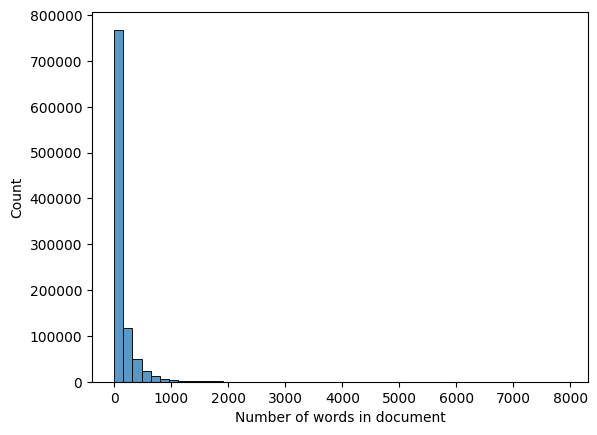

In [3]:
doc_lengths = [text.count(" ") + 1 for text in text_data]
sns.histplot(doc_lengths, bins=50)
plt.xlabel("Number of words in document")

### Tokenize Data

I will tokenize the data here with a basic tokenizer, but we can use anything. 

Note that I am keeping punctuation, and creating it as a separate token. This is a choice, and one that we probably would not do for classification. If we need to create text, we need to be able to create punctuation, so the model needs to learn it. 

In [4]:
def tokenizerKeepPunctuation(text, strip_punctuation=False):
    # strip empty lines
    text_tmp = text.replace("\n", " ")
    with_split_punctuation = [".", ",", "!", "?", ";", ":"]
    for p in with_split_punctuation:
        text_tmp = text_tmp.replace(p, f" {p} ")
    if strip_punctuation:
        text_tmp = text_tmp.strip(" .,!?;: ")
    return text_tmp.split()

def vocab_from_tokenized_text(tokenized_text):
    vocab = set()
    for tokens in tokenized_text:
        vocab.update(tokens)
    return sorted(vocab), {word: idx for idx, word in enumerate(sorted(vocab))}

print(type(text_data))

tokenized_text = [tokenizerKeepPunctuation(text) for text in text_data]
print(f"Tokenized text shape: {len(tokenized_text)}")
tokenized_text[0]

<class 'list'>
Tokenized text shape: 988190


["I've",
 'always',
 'been',
 'great',
 'with',
 'children',
 '.',
 'I',
 'used',
 'to',
 'nanny',
 'and',
 'do',
 'summer',
 'camps',
 'etc',
 '.',
 'however',
 'when',
 'I',
 'got',
 'my',
 'first',
 'job',
 'in',
 'a',
 'preschool',
 'things',
 'were',
 'out',
 'of',
 'control',
 '.',
 'we',
 'were',
 'under',
 'staffed',
 'and',
 'I',
 'got',
 'EXTEREMLY',
 'overwhelmed',
 '.',
 'I',
 'was',
 'so',
 'stressed',
 'and',
 'overstimulated',
 '.',
 'Most',
 'of',
 'the',
 'children',
 'were',
 'great/',
 'easy',
 'to',
 'work',
 'with',
 ',',
 'but',
 'these',
 '2',
 'problem',
 'children',
 'drove',
 'me',
 'crazy',
 '.',
 'I',
 'engaged',
 'in',
 'power',
 'struggles',
 'with',
 'them',
 'and',
 'would',
 'sometimes',
 'be',
 'stubborn',
 'or',
 'insist',
 'on',
 'the',
 'rules',
 'rather',
 'than',
 'be',
 'gentle',
 'and',
 'allow',
 'this',
 'little',
 'overwhelmed',
 'child',
 'to',
 'have',
 'some',
 'control',
 'over',
 'their',
 'environment',
 '.',
 'I',
 'would',
 'get',
 'a

In [ ]:
def generatePaddedSequences(data, sequence_length=100, max_number=1000):
    """Create variable-length sequences (up to sequence_length) with targets.
    
    For each position in the text, the input is the preceding tokens
    (up to sequence_length), and the target is the current token.
    Shorter sequences will be padded later by the collate_fn.
    """
    sequences = []
    for text in data:
        words = tokenizerKeepPunctuation(text)
        for i in range(1, len(words)):
            start = max(0, i - sequence_length)
            x = words[start:i]
            y = words[i]
            sequences.append((x, y))
            if len(sequences) >= max_number:
                return sequences[:max_number]
    return sequences

sequences = generatePaddedSequences(text_data, sequence_length=100, max_number=100000)
print("Created {} sequences".format(len(sequences)))
print("Example sequence (length {}):".format(len(sequences[0][0])))
print(f"\nShortest input length: {min(len(s[0]) for s in sequences)}")
print(f"Longest input length: {max(len(s[0]) for s in sequences)}")

print("Input:", sequences[8][0])
print("Target:", sequences[8][1])
print("\n\n")
print("Input:", sequences[275][0])
print("Target:", sequences[275][1])

Created 100000 sequences
Example sequence (length 1):
Input: (["I've"], 'always')
Target: always

Shortest input length: 1
Longest input length: 100


In [ ]:
class LSTM_Generation_Dataset(Dataset):
    def __init__(self, sequences, vocab_dict):
        self.sequences = sequences
        self.vocab_dict = vocab_dict

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        x, y = self.sequences[idx]
        x_indices = [self.vocab_dict[word] for word in x]
        y_index = self.vocab_dict[y]
        return torch.tensor(x_indices), torch.tensor(y_index)
    
    def get_vocab(self):
        return self.vocab_dict

def collate_fn(batch, pad_value=0):
    x_batch, y_batch = zip(*batch)
    x_batch_lengths = torch.tensor([len(x) for x in x_batch])
    # Right-pad sequences (required for pack_padded_sequence)
    x_batch_padded = pad_sequence(x_batch, batch_first=True, padding_value=pad_value)
    y_batch = torch.stack(y_batch)
    return x_batch_padded, x_batch_lengths, y_batch

## Model

The model isn't all that different from any other LSTM model, the main difference is that we aim it to predict the next word, or more accurately, the vector of the next token. 

### Talk Nerdy to Me

Generating text is very much like forecasting in a regular time series. We have a sequence of tokens, normally called the seed text, that we feed to the model, which will then predict the next token. We then take that predicted token, add it to the end of the seed text, and feed it back into the model to get the next token and so on. 

<b>Note:</b> Production LLMs vary a little bit in how they work, the raw model is generally wrapped in some code to manage the interaction, keep a history, and make sure responses are appropriate. A user doesn't get the raw model responses like we are getting here. Those also generally use a different tokenization method called byte pair encoding, which basically breaks words into subwords, so a prediction of a token "ski" might be followed by a prediction of "ing", "er", or " trip" (with a space at the beginning). Combined with a large vocabulary and training data, this allows the model to be able to learn to generate language in a more realistic way. 

### Temperature

By default, a model wants to predict the correct result, in this case it wants to predict the most likely next word. At a high level, this is good, but when we look at it closer, this won't really work for something that sounds natural. If we always pick the most likely next word, we will end up with a model that is very repetitive and mechanical. 

To get around this, most generative models use something to randomize the responses somewhat. Instead of always picking the most likely next token, it will pick one of a set of likely next tokens. This allows the model to vary the exact output, while still being likely to be correct. The temperature is a parameter that controls how much randomness we want. A low temperature will make the model more likely to pick the most likely next token, while a high temperature will make it more likely to pick a less likely next token.

There are several different methods to do this randomization.

#### Hidden State vs Output

In the forward pass, you may notice that the value that is used is taken from the most recent hidden state, not the output. This is because the output is a vector of probabilities for each token, while the hidden state is a vector that contains the information about the sequence. The output is generated from the hidden state, so it contains all the information about the sequence, but it is not as useful for generating text as the hidden state. The hidden state is what we want to use to generate the next token, because it contains all the information about the sequence, while the output is just a probability distribution over the next token.

In [ ]:
class LSTM_Generator(nn.Module):
    def __init__(self, vocab_size, vocab_dict, embedding_dim=256, hidden_dim=256, num_layers=3, dropout=.3, pad_idx=0):
        super(LSTM_Generator, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout, bidirectional=False)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.vocab_dict = vocab_dict
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
    
    def forward(self, x, lengths=None):
        embedded = self.embedding(x)
        
        if lengths is not None:
            # Pack padded sequences so the LSTM ignores padding tokens
            packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
            _, (h_n, c_n) = self.lstm(packed)
        else:
            _, (h_n, c_n) = self.lstm(embedded)
        
        # h_n shape: (num_layers, batch, hidden_dim) for unidirectional
        # h_n[-1] is the last layer's final hidden state: (batch, hidden_dim)
        output = self.fc(h_n[-1])
        return output
    
    def providePredictedToken(self, input_value, temperature=1.0):
        self.eval()
        with torch.no_grad():
            input_value = input_value.to(DEVICE)
            output = self(input_value)
            probabilities = torch.softmax(output / temperature, dim=1)
            predicted_idx = torch.multinomial(probabilities, num_samples=1).item()
            predicted_word = list(self.vocab_dict.keys())[list(self.vocab_dict.values()).index(predicted_idx)]
        return predicted_word
    
    def recursive_prediction(self, seed_text, max_length=50):
        self.eval()
        generated = seed_text.split()
        for _ in range(max_length):
            input_seq = torch.tensor([[self.vocab_dict.get(word, 0) for word in generated[-100:]]])
            with torch.no_grad():
                input_seq = input_seq.to(DEVICE)
                output = self.providePredictedToken(input_seq)
                generated.append(output)
        return " ".join(generated)

In [ ]:
def train_model(model, train_loader, num_epochs=10, learning_rate=0.001, example_seeds=None, print_batch=False):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for i, (x_batch, x_lengths, y_batch) in enumerate(train_loader):
            x_batch, x_lengths, y_batch = x_batch.to(DEVICE), x_lengths.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(x_batch, lengths=x_lengths)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            if print_batch:
                print("Batch number {} of {}:".format(i+1, len(train_loader)) + " Loss: {:.4f}".format(loss.item()))
        
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
        if not example_seeds is None:
            for seed_ in example_seeds:
                sample_output_1 = model.recursive_prediction(seed_)
                print("Sample:", sample_output_1)
        

### Padding the Stats

We can setup the padding token, the value that is inserted to fill dead space when generating sequences. This code is pretty standard, and basically starts the dictionary of tokens with an entry of <PAD> mapped to 0. All other token values will start after that. 

In [ ]:
# Set Batch Size - The speed is a concern here
# You may need/want to dial this back to git in GPU memory. 
batch_size = 512
epochs = 20

vocab = set()
for tokens in tokenized_text:
    vocab.update(tokens)
vocab = sorted(vocab)

# Reserve index 0 for <PAD> token, shift all real words to index 1+
PAD_TOKEN = "<PAD>"
vocab_dict = {PAD_TOKEN: 0}
vocab_dict.update({word: idx + 1 for idx, word in enumerate(vocab)})
vocab_size = len(vocab_dict)  # includes <PAD>

seeds = ["I want to go to school today because ",
         "The last time we played soccer was very ",
         "There aren't very many children, but there are many "]

train_dataset = LSTM_Generation_Dataset(sequences, vocab_dict=vocab_dict)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
model = LSTM_Generator(vocab_size=vocab_size, vocab_dict=vocab_dict)

### Train Time

We can train our model. This will take a long time to get a model that is anywhere near good, likely far longer than we have the resources or patience to do. In real life, this is an application where the ability to have datasets and training monitoring that can be distributed across multiple machines is very important.

It may run counter to what we'd assume, but most massive LLMs are trained with only one or two epochs. The training data is so large, that the model ends up "seeing" similar things in language multiple times, so the marginal benefit of adding another (potentially expensive) epoch is not worth it. If we think of generating something like "skiing" vs "skier", the model will need enough examples so that it can differentiate which should be used, given the context. Note that this doesn't necessarily mean those exact words, other uses of "ing" vs "er", for example, will overlap in what the model learns. 

In [11]:
train_model(model, train_loader, num_epochs=epochs, learning_rate=0.001, example_seeds=seeds, print_batch=True)

Batch number 1 of 196: Loss: 13.1689
Batch number 2 of 196: Loss: 13.1598
Batch number 3 of 196: Loss: 13.1443
Batch number 4 of 196: Loss: 13.1243
Batch number 5 of 196: Loss: 13.0941
Batch number 6 of 196: Loss: 13.0455


KeyboardInterrupt: 